In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
customers = pd.read_csv("r F:\banking_customer_transaction_analytics\banking_customer_transaction_analytics\customers.csv")
accounts = pd.read_csv("r F:\banking_customer_transaction_analytics\banking_customer_transaction_analytics\accounts.csv")
products = pd.read_csv("r F:\banking_customer_transaction_analytics\banking_customer_transaction_analytics\products.csv")
transactions = pd.read_csv("r F:\banking_customer_transaction_analytics\banking_customer_transaction_analytics\transactions.csv")
customer_products = pd.read_csv("r F:\banking_customer_transaction_analytics\banking_customer_transaction_analytics\customer_products.csv")

FileNotFoundError: File b'r F:\x08anking_customer_transaction_analytics\x08anking_customer_transaction_analytics\\customers.csv' does not exist

In [3]:
customers = pd.read_csv(
    r"F:\banking_customer_transaction_analytics\data\customers.csv"
)

accounts = pd.read_csv(
    r"F:\banking_customer_transaction_analytics\data\accounts.csv"
)

products = pd.read_csv(
    r"F:\banking_customer_transaction_analytics\data\products.csv"
)

transactions = pd.read_csv(
    r"F:\banking_customer_transaction_analytics\data\transactions.csv"
)

customer_products = pd.read_csv(
    r"F:\banking_customer_transaction_analytics\data\customer_products.csv"
)

print("All files loaded successfully!")


All files loaded successfully!


In [4]:
print("Customers:", customers.shape)
print("Accounts:", accounts.shape)
print("Products:", products.shape)
print("Transactions:", transactions.shape)
print("Customer Products:", customer_products.shape)

Customers: (5000, 8)
Accounts: (7500, 5)
Products: (8, 3)
Transactions: (120000, 7)
Customer Products: (8261, 3)


In [5]:
customers.head()

,customer_id,customer_name,age,gender,city,segment,join_date,age_group
0,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59
1,C00002,Customer 00002,49,Male,Jaipur,Affluent,2021-07-18,40-49
2,C00003,Customer 00003,35,Male,Kolkata,Mass,2023-03-26,30-39
3,C00004,Customer 00004,63,Male,Chennai,Mass,2024-09-08,60+
4,C00005,Customer 00005,28,Female,Hyderabad,Mass,2024-09-17,21-29


In [6]:
transactions.head()

,transaction_id,account_id,transaction_date,transaction_type,amount,channel,transaction_month
0,T000001,A00260,2025-07-21,Credit,1373.40,Internet Banking,2025-07
1,T000002,A01755,2025-04-20,Debit,1138.39,Internet Banking,2025-04
2,T000003,A02398,2025-07-11,Credit,511.30,UPI,2025-07
3,T000004,A04803,2025-12-15,Debit,929.08,UPI,2025-12
4,T000005,A00046,2025-07-31,Debit,3430.63,ATM,2025-07


In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
customer_id      5000 non-null object
customer_name    5000 non-null object
age              5000 non-null int64
gender           5000 non-null object
city             5000 non-null object
segment          5000 non-null object
join_date        5000 non-null object
age_group        5000 non-null object
dtypes: int64(1), object(7)
memory usage: 312.6+ KB


In [8]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 7 columns):
transaction_id       120000 non-null object
account_id           120000 non-null object
transaction_date     120000 non-null object
transaction_type     120000 non-null object
amount               120000 non-null float64
channel              120000 non-null object
transaction_month    120000 non-null object
dtypes: float64(1), object(6)
memory usage: 6.4+ MB


In [9]:
print("Customers missing values:")
print(customers.isnull().sum())

print("\nTransactions missing values:")
print(transactions.isnull().sum())

Customers missing values:
customer_id      0
customer_name    0
age              0
gender           0
city             0
segment          0
join_date        0
age_group        0
dtype: int64

Transactions missing values:
transaction_id       0
account_id           0
transaction_date     0
transaction_type     0
amount               0
channel              0
transaction_month    0
dtype: int64


In [10]:
print("\nAccounts missing values:")
print(accounts.isnull().sum())

print("\nProducts missing values:")
print(products.isnull().sum())

print("\nCustomer Products missing values:")
print(customer_products.isnull().sum())


Accounts missing values:
account_id      0
customer_id     0
account_type    0
open_date       0
balance         0
dtype: int64

Products missing values:
product_id      0
product_name    0
category        0
dtype: int64

Customer Products missing values:
customer_product_id    0
customer_id            0
product_id             0
dtype: int64


In [11]:
customers["join_date"] = pd.to_datetime(customers["join_date"])

accounts["open_date"] = pd.to_datetime(accounts["open_date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [12]:
print(customers["join_date"].dtype)
print(transactions["transaction_date"].dtype)

datetime64[ns]
datetime64[ns]


In [13]:
total_transactions = len(transactions)

total_transaction_value = transactions["amount"].sum()

average_transaction_value = transactions["amount"].mean()

print("Total Transactions:", total_transactions)
print("Total Transaction Value: ₹{:,.2f}".format(total_transaction_value))
print("Average Transaction Value: ₹{:,.2f}".format(average_transaction_value))

Total Transactions: 120000
Total Transaction Value: ₹228,757,184.70
Average Transaction Value: ₹1,906.31


In [14]:
monthly_transactions = (
    transactions
    .groupby("transaction_month")
    .agg(
        transaction_count=("transaction_id", "count"),
        transaction_value=("amount", "sum")
    )
    .reset_index()
)

monthly_transactions

TypeError: aggregate() missing 1 required positional argument: 'arg'

In [15]:
monthly_transactions = (
    transactions
    .groupby("transaction_month")
    .agg({
        "transaction_id": "count",
        "amount": "sum"
    })
    .reset_index()
)

monthly_transactions = monthly_transactions.rename(
    columns={
        "transaction_id": "transaction_count",
        "amount": "transaction_value"
    }
)

monthly_transactions

,transaction_month,transaction_count,transaction_value
0,2025-01,10062,19260172.83
1,2025-02,9247,17411787.21
2,2025-03,9999,18589766.45
3,2025-04,9829,18087798.61
4,2025-05,10244,19969218.81
5,2025-06,9860,18474808.97
6,2025-07,10221,19339559.75
7,2025-08,10505,20671923.88
8,2025-09,9835,18865591.30
9,2025-10,10164,19299974.65


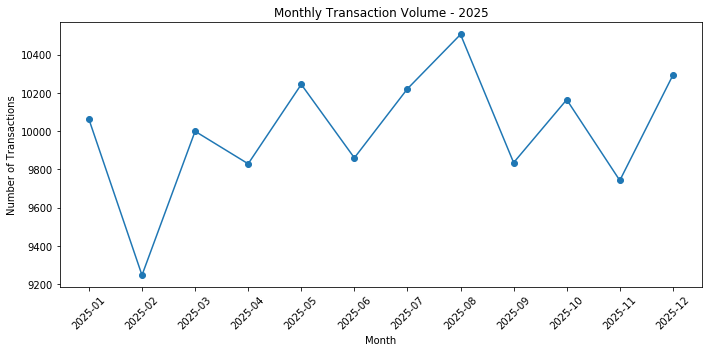

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_transactions["transaction_month"],
    monthly_transactions["transaction_count"],
    marker="o"
)

plt.title("Monthly Transaction Volume - 2025")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
transaction_type_analysis = (
    transactions
    .groupby("transaction_type")
    .agg({
        "transaction_id": "count",
        "amount": ["sum", "mean"]
    })
    .reset_index()
)

transaction_type_analysis.columns = [
    "transaction_type",
    "transaction_count",
    "transaction_value",
    "average_transaction_value"
]

transaction_type_analysis["transaction_value"] = (
    transaction_type_analysis["transaction_value"].round(2)
)

transaction_type_analysis["average_transaction_value"] = (
    transaction_type_analysis["average_transaction_value"].round(2)
)

transaction_type_analysis

,transaction_type,transaction_count,transaction_value,average_transaction_value
0,Credit,51601,9.756385e+07,1890.74
1,Debit,68399,1.311933e+08,1918.06


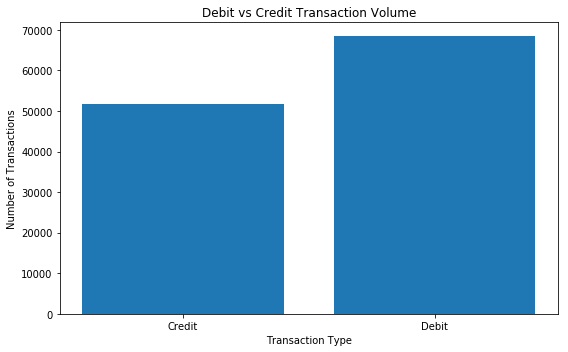

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    transaction_type_analysis["transaction_type"],
    transaction_type_analysis["transaction_count"]
)

plt.title("Debit vs Credit Transaction Volume")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [19]:
transaction_type_display = transaction_type_analysis.copy()

transaction_type_display["transaction_value"] = (
    transaction_type_display["transaction_value"]
    .map("₹{:,.2f}".format)
)

transaction_type_display["average_transaction_value"] = (
    transaction_type_display["average_transaction_value"]
    .map("₹{:,.2f}".format)
)

transaction_type_display

,transaction_type,transaction_count,transaction_value,average_transaction_value
0,Credit,51601,"₹97,563,846.99","₹1,890.74"
1,Debit,68399,"₹131,193,337.71","₹1,918.06"


In [20]:
channel_analysis = (
    transactions
    .groupby("channel")
    .agg({
        "transaction_id": "count",
        "amount": ["sum", "mean"]
    })
    .reset_index()
)

channel_analysis.columns = [
    "channel",
    "transaction_count",
    "transaction_value",
    "average_transaction_value"
]

channel_analysis["transaction_value"] = (
    channel_analysis["transaction_value"].round(2)
)

channel_analysis["average_transaction_value"] = (
    channel_analysis["average_transaction_value"].round(2)
)

channel_analysis = channel_analysis.sort_values(
    "transaction_count",
    ascending=False
)

channel_analysis

,channel,transaction_count,transaction_value,average_transaction_value
5,UPI,40909,78900638.14,1928.69
3,Mobile App,23970,45518050.70,1898.96
2,Internet Banking,19239,35913198.76,1866.69
4,POS,15587,29996887.23,1924.48
0,ATM,11913,22351801.19,1876.25
1,Branch,8382,16076608.68,1917.99


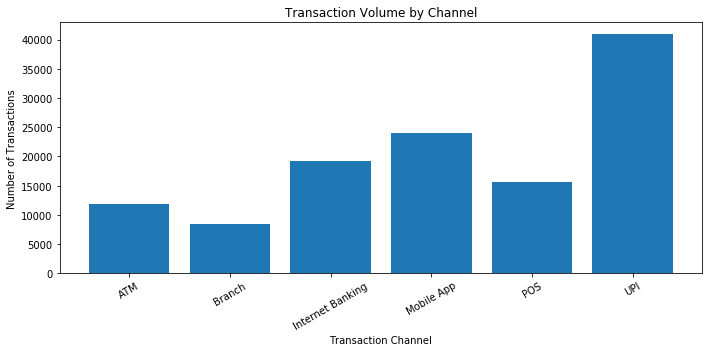

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    channel_analysis["channel"],
    channel_analysis["transaction_count"]
)

plt.title("Transaction Volume by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [22]:
segment_analysis = (
    customers
    .groupby("segment")
    .size()
    .reset_index(name="customer_count")
)

segment_analysis["customer_percentage"] = (
    segment_analysis["customer_count"]
    / len(customers)
    * 100
).round(2)

segment_analysis = segment_analysis.sort_values(
    "customer_count",
    ascending=False
)

segment_analysis

,segment,customer_count,customer_percentage
1,Mass,3071,61.42
0,Affluent,1442,28.84
2,Premium,487,9.74


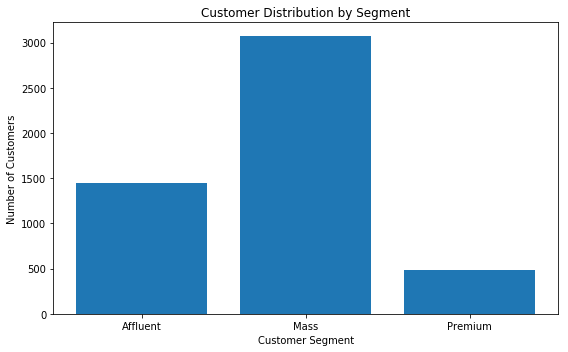

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis["segment"],
    segment_analysis["customer_count"]
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


In [24]:
customer_accounts = pd.merge(
    customers,
    accounts,
    on="customer_id",
    how="inner"
)

print("Customer-Account rows:", len(customer_accounts))
customer_accounts.head()

Customer-Account rows: 7500


,customer_id,customer_name,age,gender,city,segment,join_date,age_group,account_id,account_type,open_date,balance
0,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A05139,Savings,2023-09-24,35861.20
1,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A05353,Savings,2022-02-15,48138.11
2,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A06414,Savings,2021-04-06,78640.65
3,C00004,Customer 00004,63,Male,Chennai,Mass,2024-09-08,60+,A02325,Salary,2024-07-21,6879.70
4,C00007,Customer 00007,59,Female,Hyderabad,Mass,2021-08-05,50-59,A01657,Savings,2021-09-07,61808.88


In [25]:
customer_transactions = pd.merge(
    customer_accounts,
    transactions,
    on="account_id",
    how="inner"
)

print("Customer-Transaction rows:", len(customer_transactions))
customer_transactions.head()

Customer-Transaction rows: 120000


,customer_id,customer_name,age,gender,city,segment,join_date,age_group,account_id,account_type,open_date,balance,transaction_id,transaction_date,transaction_type,amount,channel,transaction_month
0,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A05139,Savings,2023-09-24,35861.2,T005760,2025-01-11,Credit,3022.45,UPI,2025-01
1,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A05139,Savings,2023-09-24,35861.2,T010617,2025-06-24,Credit,502.35,Branch,2025-06
2,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A05139,Savings,2023-09-24,35861.2,T010813,2025-09-21,Debit,1434.37,UPI,2025-09
3,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A05139,Savings,2023-09-24,35861.2,T012960,2025-07-04,Credit,4245.02,UPI,2025-07
4,C00001,Customer 00001,59,Male,Delhi,Premium,2024-03-13,50-59,A05139,Savings,2023-09-24,35861.2,T023853,2025-07-18,Debit,666.42,POS,2025-07


In [26]:
segment_transaction_analysis = (
    customer_transactions
    .groupby("segment")
    .agg({
        "transaction_id": "count",
        "amount": ["sum", "mean"]
    })
    .reset_index()
)

segment_transaction_analysis.columns = [
    "segment",
    "transaction_count",
    "transaction_value",
    "average_transaction_value"
]

segment_transaction_analysis["transaction_value"] = (
    segment_transaction_analysis["transaction_value"].round(2)
)

segment_transaction_analysis["average_transaction_value"] = (
    segment_transaction_analysis["average_transaction_value"].round(2)
)

segment_transaction_analysis

,segment,transaction_count,transaction_value,average_transaction_value
0,Affluent,34569,6.615022e+07,1913.57
1,Mass,73694,1.407232e+08,1909.56
2,Premium,11737,2.188373e+07,1864.51


In [27]:
# Calculate active customers by segment
active_customers_segment = (
    customer_transactions
    .groupby("segment")["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)

# Add active customer count to segment analysis
segment_transaction_analysis = pd.merge(
    segment_transaction_analysis,
    active_customers_segment,
    on="segment",
    how="left"
)

# Calculate transactions per active customer
segment_transaction_analysis["transactions_per_active_customer"] = (
    segment_transaction_analysis["transaction_count"]
    / segment_transaction_analysis["active_customers"]
).round(2)

# Calculate transaction value share
total_transaction_value = transactions["amount"].sum()

segment_transaction_analysis["transaction_value_share"] = (
    segment_transaction_analysis["transaction_value"]
    / total_transaction_value
    * 100
).round(2)

segment_transaction_analysis

,segment,transaction_count,transaction_value,average_transaction_value,active_customers,transactions_per_active_customer,transaction_value_share
0,Affluent,34569,6.615022e+07,1913.57,1107,31.23,28.92
1,Mass,73694,1.407232e+08,1909.56,2362,31.20,61.52
2,Premium,11737,2.188373e+07,1864.51,370,31.72,9.57


In [28]:
# Count transactions for each customer
customer_activity = (
    customer_transactions
    .groupby("customer_id")
    .size()
    .reset_index(name="transaction_count")
)

# Create activity buckets
def activity_bucket(count):
    if count <= 10:
        return "Low Activity"
    elif count <= 30:
        return "Moderate Activity"
    elif count <= 60:
        return "High Activity"
    else:
        return "Very High Activity"

customer_activity["activity_bucket"] = (
    customer_activity["transaction_count"]
    .apply(activity_bucket)
)

# Count customers in each bucket
activity_distribution = (
    customer_activity
    .groupby("activity_bucket")
    .size()
    .reset_index(name="customer_count")
)

activity_distribution

,activity_bucket,customer_count
0,High Activity,1408
1,Low Activity,122
2,Moderate Activity,2030
3,Very High Activity,279


In [29]:
activity_distribution["customer_percentage"] = (
    activity_distribution["customer_count"]
    / activity_distribution["customer_count"].sum()
    * 100
).round(2)

activity_distribution

,activity_bucket,customer_count,customer_percentage
0,High Activity,1408,36.68
1,Low Activity,122,3.18
2,Moderate Activity,2030,52.88
3,Very High Activity,279,7.27


In [30]:
customer_value_analysis = (
    customer_transactions
    .groupby("customer_id")
    .agg({
        "transaction_id": "count",
        "amount": ["sum", "mean"]
    })
    .reset_index()
)

customer_value_analysis.columns = [
    "customer_id",
    "transaction_count",
    "transaction_value",
    "average_transaction_value"
]

customer_value_analysis["transaction_value"] = (
    customer_value_analysis["transaction_value"].round(2)
)

customer_value_analysis["average_transaction_value"] = (
    customer_value_analysis["average_transaction_value"].round(2)
)

customer_value_analysis.head(10)

,customer_id,transaction_count,transaction_value,average_transaction_value
0,C00001,47,71870.86,1529.17
1,C00004,14,22784.50,1627.46
2,C00007,48,93068.35,1938.92
3,C00008,63,112924.88,1792.46
4,C00010,21,55681.77,2651.51
5,C00011,34,87719.12,2579.97
6,C00012,54,107587.76,1992.37
7,C00013,11,11582.55,1052.96
8,C00016,53,139376.52,2629.75
9,C00018,54,145907.61,2701.99


In [31]:
top_customers_by_value = (
    customer_value_analysis
    .sort_values(
        "transaction_value",
        ascending=False
    )
    .head(10)
)

top_customers_by_value

,customer_id,transaction_count,transaction_value,average_transaction_value
1041,C01367,108,278213.79,2576.05
3790,C04937,130,271652.50,2089.63
648,C00842,97,258657.00,2666.57
1734,C02282,101,252901.64,2503.98
2992,C03905,72,240554.68,3341.04
1514,C01997,84,230300.01,2741.67
1969,C02589,90,226201.13,2513.35
1621,C02130,106,218068.12,2057.25
968,C01269,95,217029.53,2284.52
2419,C03177,108,216992.65,2009.19


In [32]:
customer_correlation = customer_value_analysis[
    ["transaction_count", "transaction_value"]
].corr()

customer_correlation


,transaction_count,transaction_value
transaction_count,1.000000,0.913717
transaction_value,0.913717,1.000000


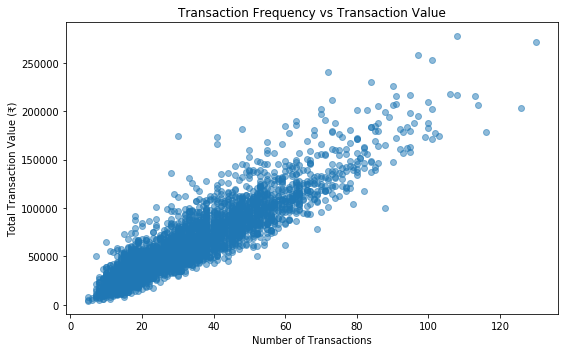

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_value_analysis["transaction_count"],
    customer_value_analysis["transaction_value"],
    alpha=0.5
)

plt.title("Transaction Frequency vs Transaction Value")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Transaction Value (₹)")

plt.tight_layout()
plt.show()

In [34]:
customer_activity_analysis = pd.merge(
    customer_value_analysis,
    customer_activity[["customer_id", "activity_bucket"]],
    on="customer_id",
    how="left"
)

customer_activity_analysis.head(10)

,customer_id,transaction_count,transaction_value,average_transaction_value,activity_bucket
0,C00001,47,71870.86,1529.17,High Activity
1,C00004,14,22784.50,1627.46,Moderate Activity
2,C00007,48,93068.35,1938.92,High Activity
3,C00008,63,112924.88,1792.46,Very High Activity
4,C00010,21,55681.77,2651.51,Moderate Activity
5,C00011,34,87719.12,2579.97,High Activity
6,C00012,54,107587.76,1992.37,High Activity
7,C00013,11,11582.55,1052.96,Moderate Activity
8,C00016,53,139376.52,2629.75,High Activity
9,C00018,54,145907.61,2701.99,High Activity


In [35]:
customer_activity_analysis = pd.merge(
    customer_activity_analysis,
    customers[["customer_id", "segment"]],
    on="customer_id",
    how="left"
)

customer_activity_analysis.head(10)

,customer_id,transaction_count,transaction_value,average_transaction_value,activity_bucket,segment
0,C00001,47,71870.86,1529.17,High Activity,Premium
1,C00004,14,22784.50,1627.46,Moderate Activity,Mass
2,C00007,48,93068.35,1938.92,High Activity,Mass
3,C00008,63,112924.88,1792.46,Very High Activity,Premium
4,C00010,21,55681.77,2651.51,Moderate Activity,Mass
5,C00011,34,87719.12,2579.97,High Activity,Mass
6,C00012,54,107587.76,1992.37,High Activity,Mass
7,C00013,11,11582.55,1052.96,Moderate Activity,Mass
8,C00016,53,139376.52,2629.75,High Activity,Affluent
9,C00018,54,145907.61,2701.99,High Activity,Mass


In [36]:
print("Rows:", len(customer_activity_analysis))
print("Columns:", len(customer_activity_analysis.columns))

customer_activity_analysis.isnull().sum()

Rows: 3839
Columns: 6


customer_id                  0
transaction_count            0
transaction_value            0
average_transaction_value    0
activity_bucket              0
segment                      0
dtype: int64

In [37]:
segment_summary = (
    customer_activity_analysis
    .groupby("segment")
    .agg({
        "customer_id": "count",
        "transaction_count": "sum",
        "transaction_value": "sum",
        "average_transaction_value": "mean"
    })
    .reset_index()
)

segment_summary.columns = [
    "segment",
    "active_customers",
    "transaction_count",
    "transaction_value",
    "average_transaction_value"
]

segment_summary["transaction_value"] = (
    segment_summary["transaction_value"].round(2)
)

segment_summary["average_transaction_value"] = (
    segment_summary["average_transaction_value"].round(2)
)

segment_summary

,segment,active_customers,transaction_count,transaction_value,average_transaction_value
0,Affluent,1107,34569,6.615022e+07,1916.71
1,Mass,2362,73694,1.407232e+08,1901.21
2,Premium,370,11737,2.188373e+07,1854.95


In [38]:
activity_summary = (
    customer_activity_analysis
    .groupby("activity_bucket")
    .agg({
        "customer_id": "count",
        "transaction_count": "sum",
        "transaction_value": "sum"
    })
    .reset_index()
)

activity_summary.columns = [
    "activity_bucket",
    "customer_count",
    "transaction_count",
    "transaction_value"
]

activity_summary["transaction_value"] = (
    activity_summary["transaction_value"].round(2)
)

activity_summary

,activity_bucket,customer_count,transaction_count,transaction_value
0,High Activity,1408,59190,1.125982e+08
1,Low Activity,122,1097,2.144608e+06
2,Moderate Activity,2030,39037,7.434047e+07
3,Very High Activity,279,20676,3.967386e+07


In [39]:
channel_summary = channel_analysis.copy()

channel_summary

,channel,transaction_count,transaction_value,average_transaction_value
5,UPI,40909,78900638.14,1928.69
3,Mobile App,23970,45518050.70,1898.96
2,Internet Banking,19239,35913198.76,1866.69
4,POS,15587,29996887.23,1924.48
0,ATM,11913,22351801.19,1876.25
1,Branch,8382,16076608.68,1917.99
